# Setup Library

In [ ]:
!pip install sastrawi
!pip install tensorflow
!pip install gensim
!pip install tqdm
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.initializers import Constant
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from tqdm import tqdm
tqdm.pandas()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
import pandas as pd

try:
    dataset = pd.read_csv(r"/content/drive/MyDrive/SKRIPSI/DATASET-PREPROCESSING.csv")
except FileNotFoundError:
    print("⚠️ File dataset tidak ditemukan.")
    dataset = pd.DataFrame({'Ulasan': [], 'produk': []})

dataset['Review'] = dataset['Ulasan'].fillna('')

print(f"Jumlah data: {len(dataset)}")
dataset.head()

Jumlah data: 10825


,Ulasan,Produk,Review
0,Dicas bukan makin nambah malah makin berkurang...,X15 TWS Wireless Bluetooth Headset Waterproof ...,Dicas bukan makin nambah malah makin berkurang...
1,Kalau ga niat jualan gausah jualan barang rusa...,X15 TWS Wireless Bluetooth Headset Waterproof ...,Kalau ga niat jualan gausah jualan barang rusa...
2,Ga bisa nyala dan ga bisa di cas sudah percaya...,X15 TWS Wireless Bluetooth Headset Waterproof ...,Ga bisa nyala dan ga bisa di cas sudah percaya...
3,Maaf kak ini maksudnya gimana ya?,X15 TWS Wireless Bluetooth Headset Waterproof ...,Maaf kak ini maksudnya gimana ya?
4,"Barang sudah sampai, kotak aman packingan rapi...",X15 TWS Wireless Bluetooth Headset Waterproof ...,"Barang sudah sampai, kotak aman packingan rapi..."


# Explorasi Data Analisis

## Panjang Kata

In [ ]:
# Hitung frekuensi tiap panjang kata

dataset['panjang_kata'] = dataset['Review'].apply(lambda x: len(str(x).split()))

distribusi_panjang = (
    dataset["panjang_kata"]
    .value_counts()
    .sort_index()
)

distribusi_panjang.head(10)

# Ensure the last bin edge is always strictly greater than 100, and also covers the max observed value.
max_observed_len = dataset["panjang_kata"].max()
# The last bin edge should be at least 101 to be strictly greater than 100,
# and also sufficiently large to cover max_observed_len.
# Use max(101, max_observed_len) to ensure this.
bins = [0, 5, 10, 20, 50, 100, max(101, max_observed_len)]
labels = ["1–5", "6–10", "11–20", "21–50", "51–100", ">100"]

dataset["kelompok_panjang"] = pd.cut(
    dataset["panjang_kata"],
    bins=bins,
    labels=labels,
    right=True
)

distribusi_kelompok = dataset["kelompok_panjang"].value_counts().sort_index()
distribusi_kelompok

,count
kelompok_panjang,
1–5,3144
6–10,3336
11–20,2891
21–50,1389
51–100,0
>100,2


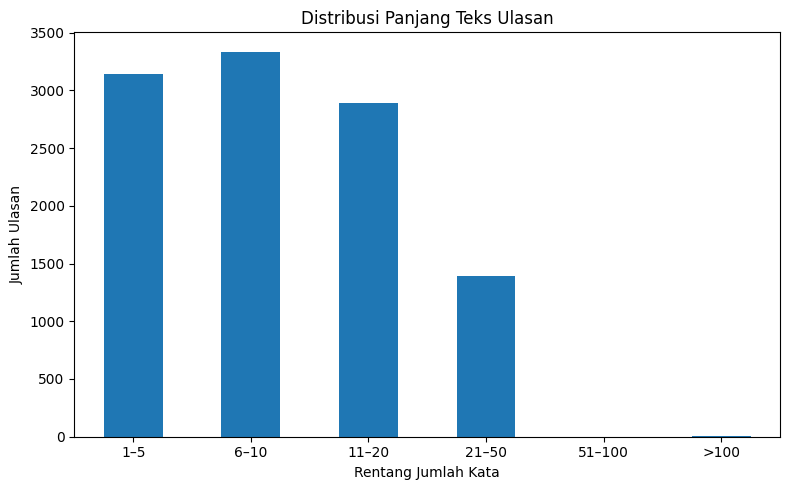

In [ ]:
import matplotlib.pyplot as plt

distribusi_kelompok.plot(kind="bar", figsize=(8, 5))

plt.title("Distribusi Panjang Teks Ulasan")
plt.xlabel("Rentang Jumlah Kata")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
dataset["panjang_kata"].describe()

,panjang_kata
count,10825.000000
mean,11.046836
std,34.609560
min,0.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,2987.000000


## Outlier

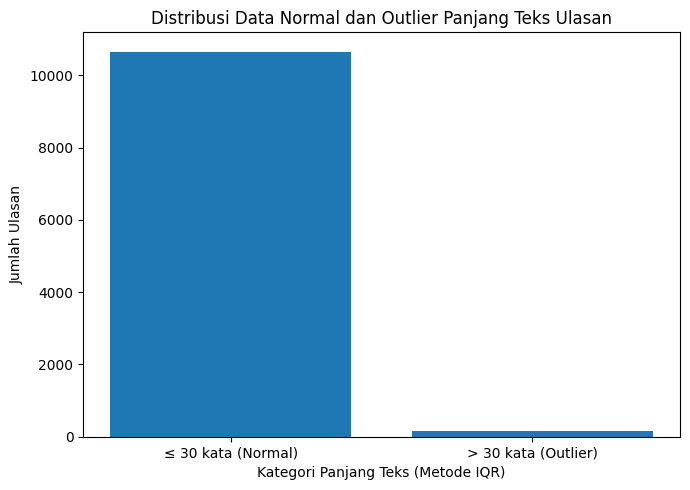

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure 'panjang_kata' is created if not already present
dataset['panjang_kata'] = dataset['Review'].apply(lambda x: len(str(x).split()))

# Hitung IQR
Q1 = dataset['panjang_kata'].quantile(0.25)
Q3 = dataset['panjang_kata'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

# Kategorisasi berdasarkan IQR
dataset["kategori_panjang"] = dataset["panjang_kata"].apply(
    lambda x: "≤ 30 kata (Normal)" if x <= batas_atas else "> 30 kata (Outlier)"
)

# Hitung jumlah per kategori
bar_data = dataset["kategori_panjang"].value_counts()

# Bar chart
plt.figure(figsize=(7, 5))
plt.bar(bar_data.index, bar_data.values)

plt.title("Distribusi Data Normal dan Outlier Panjang Teks Ulasan")
plt.xlabel("Kategori Panjang Teks (Metode IQR)")
plt.ylabel("Jumlah Ulasan")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Pastikan kolom panjang_kata sudah dibuat (seperti yang Anda tulis)
dataset['panjang_kata'] = dataset['Review'].apply(lambda x: len(str(x).split()))

# 2. Tampilkan statistik deskriptif awal
print("Statistik Deskriptif:")
display(dataset[['panjang_kata']].describe())

# 3. Hitung Kuartil dan IQR
Q1 = dataset['panjang_kata'].quantile(0.25)
Q3 = dataset['panjang_kata'].quantile(0.75)
IQR = Q3 - Q1

# 4. Tentukan Batas Outlier
# Rumus: Batas Atas = Q3 + 1.5 * IQR
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"\nBatas Bawah Outlier: {batas_bawah}")
print(f"Batas Atas Outlier: {batas_atas}")

# 5. Filter data yang merupakan outlier
outliers = dataset[dataset['panjang_kata'] > batas_atas]
outliers_bawah = dataset[dataset['panjang_kata'] < batas_bawah]

print(f"Jumlah Outlier Atas (Teks terlalu panjang): {len(outliers)}")
print(f"Jumlah Outlier Bawah (Teks terlalu pendek): {len(outliers_bawah)}")

# 6. Tampilkan 5 data ulasan terpanjang (Outlier Teratas)
print("\n5 Ulasan dengan kata terbanyak (Potensi Outlier):")
display(outliers.sort_values(by='panjang_kata', ascending=False).head())

Statistik Deskriptif:


,panjang_kata
count,10825.000000
mean,11.046836
std,34.609560
min,0.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,2987.000000



Batas Bawah Outlier: -10.0
Batas Atas Outlier: 30.0
Jumlah Outlier Atas (Teks terlalu panjang): 171
Jumlah Outlier Bawah (Teks terlalu pendek): 0

5 Ulasan dengan kata terbanyak (Potensi Outlier):


,Ulasan,Produk,Review,panjang_kata,kelompok_panjang,kategori_panjang
5346,Fitur Terbaik: Sangat Worth it! Sepadan dengan...,NaN,Fitur Terbaik: Sangat Worth it! Sepadan dengan...,2987,>100,> 30 kata (Outlier)
5351,"Barang original, sangat bagus, packingnya rapi...",NaN,"Barang original, sangat bagus, packingnya rapi...",1878,>100,> 30 kata (Outlier)
8125,Waduhh k gimana nii.. q barusan abz cas ampe f...,Review 【COD】WhatPlus x55 Headphone TWS Bluetoo...,Waduhh k gimana nii.. q barusan abz cas ampe f...,38,21–50,> 30 kata (Outlier)
8033,Sori baru kasih ulasan yg pertama di pake ya s...,Review 【COD】WhatPlus x55 Headphone TWS Bluetoo...,Sori baru kasih ulasan yg pertama di pake ya s...,38,21–50,> 30 kata (Outlier)
1170,ngga sesuai SM barang ini yg ke 2 sy beli ko g...,Official Smartwatch 10 Pro Max 100%baruOrigina...,ngga sesuai SM barang ini yg ke 2 sy beli ko g...,37,21–50,> 30 kata (Outlier)


## Hitung Frekuensi Kata

In [ ]:
from collections import Counter
import re

def clean_simple(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

all_words = []
for review in dataset['Review']:
    cleaned = clean_simple(review)
    all_words.extend(cleaned.split())

word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.most_common(10), columns=['Kata', 'Frekuensi'])
word_freq_df


,Kata,Frekuensi
0,nya,3414
1,di,2602
2,bagus,2358
3,barang,1827
4,dan,1697
5,yg,1305
6,pecah,1271
7,bisa,1256
8,sesuai,1244
9,ada,1140


## Kata yang sering muncul

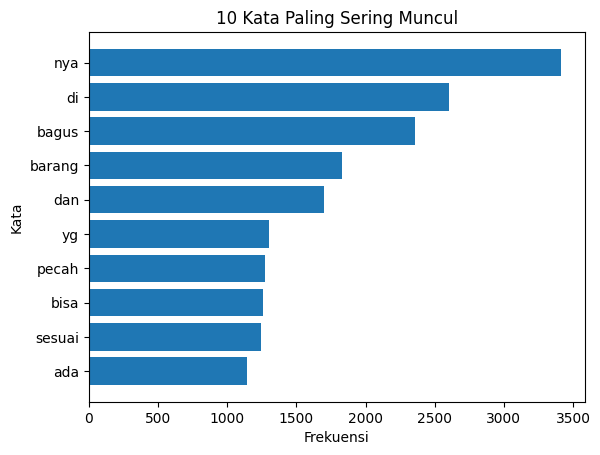

In [ ]:
plt.figure()
plt.barh(word_freq_df['Kata'], word_freq_df['Frekuensi'])
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.title("10 Kata Paling Sering Muncul")
plt.gca().invert_yaxis()
plt.show()


## WordCloud

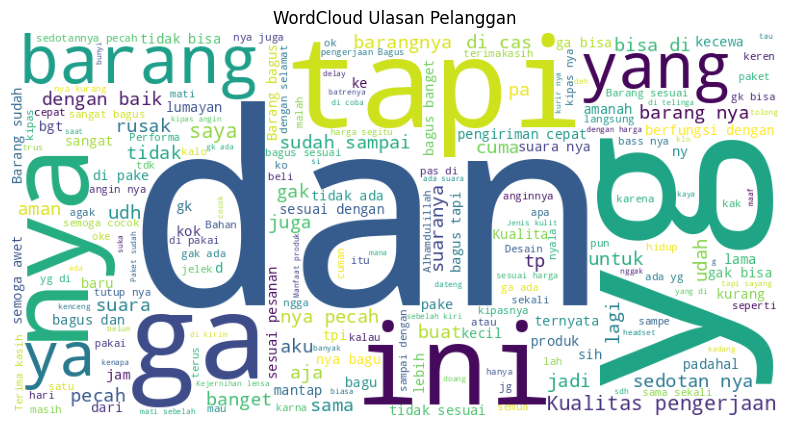

In [ ]:
from wordcloud import WordCloud

text_all = " ".join(dataset['Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud Ulasan Pelanggan")
plt.show()


## Ringkasan EDA

In [ ]:
print("Ringkasan EDA:")
print(f"- Total data ulasan: {len(dataset)}")
print(f"- Rata-rata panjang ulasan: {dataset['panjang_kata'].mean():.2f} kata")
print(f"- Panjang ulasan terpendek: {dataset['panjang_kata'].min()} kata")
print(f"- Panjang ulasan terpanjang: {dataset['panjang_kata'].max()} kata")


Ringkasan EDA:
- Total data ulasan: 10825
- Rata-rata panjang ulasan: 11.05 kata
- Panjang ulasan terpendek: 0 kata
- Panjang ulasan terpanjang: 2987 kata


# Preprocessing Data

## Cleaning Teks

In [ ]:
import string
def cleaning_text(text):
    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus emoji
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
dataset['ulasan_clean'] = dataset['Review'].apply(cleaning_text)

#save hasil
dataset[['Review', 'ulasan_clean']].to_csv(
    'ReviewClean.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil pembersihan teks telah disimpan ke 'ReviewClean.csv'")
dataset[['Review', 'ulasan_clean']].head(10)


✅ Hasil pembersihan teks telah disimpan ke 'ReviewClean.csv'


,Review,ulasan_clean
0,Dicas bukan makin nambah malah makin berkurang...,Dicas bukan makin nambah malah makin berkurang...
1,Kalau ga niat jualan gausah jualan barang rusa...,Kalau ga niat jualan gausah jualan barang rusa...
2,Ga bisa nyala dan ga bisa di cas sudah percaya...,Ga bisa nyala dan ga bisa di cas sudah percaya...
3,Maaf kak ini maksudnya gimana ya?,Maaf kak ini maksudnya gimana ya
4,"Barang sudah sampai, kotak aman packingan rapi...",Barang sudah sampai kotak aman packingan rapih...
5,Kenapa menjual produk yg tidak berfungsi😭😭 tid...,Kenapa menjual produk yg tidak berfungsi tidak...
6,"kecewa, gpaket gx pake bubble, rusak kaya keti...",kecewa gpaket gx pake bubble rusak kaya ketind...
7,Udh dateng tapi yang satu ga nyalaaa!!!!,Udh dateng tapi yang satu ga nyalaaa
8,"Barang ny bagus,cuma ujung headset ny g ada ka...",Barang ny baguscuma ujung headset ny g ada kar...
9,Pengiriman lambat dan lobang casannya miring,Pengiriman lambat dan lobang casannya miring


## Case Folding


In [ ]:
def case_folding(text):
    return text.lower()
dataset['case_folding'] = dataset['ulasan_clean'].apply(case_folding)

dataset[['ulasan_clean', 'case_folding']].to_csv('case_folding.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil case folding telah disimpan ke 'tokped_case_folding.csv'")
dataset[['ulasan_clean', 'case_folding']].head(10)

✅ Hasil case folding telah disimpan ke 'tokped_case_folding.csv'


,ulasan_clean,case_folding
0,Dicas bukan makin nambah malah makin berkurang...,dicas bukan makin nambah malah makin berkurang...
1,Kalau ga niat jualan gausah jualan barang rusa...,kalau ga niat jualan gausah jualan barang rusa...
2,Ga bisa nyala dan ga bisa di cas sudah percaya...,ga bisa nyala dan ga bisa di cas sudah percaya...
3,Maaf kak ini maksudnya gimana ya,maaf kak ini maksudnya gimana ya
4,Barang sudah sampai kotak aman packingan rapih...,barang sudah sampai kotak aman packingan rapih...
5,Kenapa menjual produk yg tidak berfungsi tidak...,kenapa menjual produk yg tidak berfungsi tidak...
6,kecewa gpaket gx pake bubble rusak kaya ketind...,kecewa gpaket gx pake bubble rusak kaya ketind...
7,Udh dateng tapi yang satu ga nyalaaa,udh dateng tapi yang satu ga nyalaaa
8,Barang ny baguscuma ujung headset ny g ada kar...,barang ny baguscuma ujung headset ny g ada kar...
9,Pengiriman lambat dan lobang casannya miring,pengiriman lambat dan lobang casannya miring


## Tokenizing

In [ ]:
import nltk
nltk.download('punkt_tab')

def tokenizing(text):
    return word_tokenize(text)
dataset['tokenized'] = dataset['case_folding'].apply(tokenizing)
dataset[['case_folding', 'tokenized']].to_csv(
    'tokped_tokenized.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil tokenisasi telah disimpan ke 'tokped_tokenized.csv'")
dataset[['case_folding', 'tokenized']].head(10)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Hasil tokenisasi telah disimpan ke 'tokped_tokenized.csv'


,case_folding,tokenized
0,dicas bukan makin nambah malah makin berkurang...,"[dicas, bukan, makin, nambah, malah, makin, be..."
1,kalau ga niat jualan gausah jualan barang rusa...,"[kalau, ga, niat, jualan, gausah, jualan, bara..."
2,ga bisa nyala dan ga bisa di cas sudah percaya...,"[ga, bisa, nyala, dan, ga, bisa, di, cas, suda..."
3,maaf kak ini maksudnya gimana ya,"[maaf, kak, ini, maksudnya, gimana, ya]"
4,barang sudah sampai kotak aman packingan rapih...,"[barang, sudah, sampai, kotak, aman, packingan..."
5,kenapa menjual produk yg tidak berfungsi tidak...,"[kenapa, menjual, produk, yg, tidak, berfungsi..."
6,kecewa gpaket gx pake bubble rusak kaya ketind...,"[kecewa, gpaket, gx, pake, bubble, rusak, kaya..."
7,udh dateng tapi yang satu ga nyalaaa,"[udh, dateng, tapi, yang, satu, ga, nyalaaa]"
8,barang ny baguscuma ujung headset ny g ada kar...,"[barang, ny, baguscuma, ujung, headset, ny, g,..."
9,pengiriman lambat dan lobang casannya miring,"[pengiriman, lambat, dan, lobang, casannya, mi..."


## Normalizing

In [ ]:
import pandas as pd

slang_path = r"slang_indo.csv"
slang_df = pd.read_csv(slang_path, header=None)

slang_df.columns = ['slang', 'formal']

slang_df['slang'] = slang_df['slang'].astype(str).str.lower().str.strip()
slang_df['formal'] = slang_df['formal'].astype(str).str.lower().str.strip()

norm_dict = dict(zip(slang_df['slang'], slang_df['formal']))

print(f"Jumlah kata slang dalam kamus: {len(norm_dict)}")

def normalizing(tokens):
    if not isinstance(tokens, list):
        return []
    return [norm_dict.get(word, word) for word in tokens]

dataset['normalized'] = dataset['tokenized'].apply(normalizing)

dataset[['tokenized', 'normalized']].to_csv(
    'tokped_normalized.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil normalisasi telah disimpan ke 'tokped_normalized.csv'")
dataset[['tokenized', 'normalized']].head(10)


Jumlah kata slang dalam kamus: 1250
✅ Hasil normalisasi telah disimpan ke 'tokped_normalized.csv'


,tokenized,normalized
0,"[dicas, bukan, makin, nambah, malah, makin, be...","[dicas, bukan, makin, tambah, malah, makin, be..."
1,"[kalau, ga, niat, jualan, gausah, jualan, bara...","[kalau, tidak, niat, jualan, tidak usah, juala..."
2,"[ga, bisa, nyala, dan, ga, bisa, di, cas, suda...","[tidak, bisa, nyala, dan, tidak, bisa, di, cas..."
3,"[maaf, kak, ini, maksudnya, gimana, ya]","[maaf, kak, ini, maksudnya, gimana, ya]"
4,"[barang, sudah, sampai, kotak, aman, packingan...","[barang, sudah, sampai, kotak, aman, packingan..."
5,"[kenapa, menjual, produk, yg, tidak, berfungsi...","[kenapa, menjual, produk, yang, tidak, berfung..."
6,"[kecewa, gpaket, gx, pake, bubble, rusak, kaya...","[kecewa, gpaket, tidak, pakai, bubble, rusak, ..."
7,"[udh, dateng, tapi, yang, satu, ga, nyalaaa]","[sudah, datang, tapi, yang, satu, tidak, nyalaaa]"
8,"[barang, ny, baguscuma, ujung, headset, ny, g,...","[barang, ny, baguscuma, ujung, headset, ny, ti..."
9,"[pengiriman, lambat, dan, lobang, casannya, mi...","[pengiriman, lambat, dan, lobang, casannya, mi..."


## Stopword Removal

In [ ]:
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))
kata_negasi = {'tidak', 'tak', 'jangan', 'bukan', 'kurang', 'gak', 'ga', 'belum', 'no'}
stop_words = stop_words.difference(kata_negasi)

# stopwords_tambahan = {
#     "yang","dan","di","ke","dari","pada","oleh","untuk","agar","karena","sehingga",
#     "itu","ini","ada","adalah","jadi","udah","sudah","lagi","aja","pun","dong",
#     "kayak","kayaknya","yah","ya","gitu","deh","sih","atau","dengan","tanpa",
#     "semua","setiap","cuma","misal","contoh","seperti","maupun","biasa","lebih",
#     "lumayan","agak","semoga","moga","gini","gitu","akan","tetap","bakal",
#     "produk","barang","item","seller","penjual","pembeli","buyer","customer","toko",
#     "admin","cs","kurir","ekspedisi","jne","jnt","sicepat","pengiriman","kirim",
#     "dikirim","sampai","nyampe","datang","resi","awb","lapak","etalase","variasi",
#     "warna","ukuran","opsi","pesan","order","bayar","belanja","wishlist","favorit",
#     "bahan","aroma","tekstur","kemasan","packaging","packing","isi","jumlah","pcs",
#     "keterangan","deskripsi","fitur","fungsi","box","dus","bubble","segel",
#     "harga","ongkir","voucher","promo","diskon","bonus","gratis","kode","flash","cod",
#     "total","cicilan","keranjang",
#     "hmm","eh","loh","yaampun","wkwk","haha","hehe","hihi","ok","oke","okelah",
#     "yg", "dgn", "dg", "dr", "kalo", "klo", "bs", "bisa"
# }
# stop_words.update(stopwords_tambahan)

def stopword_removal(tokens):
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return [word for word in tokens if word not in stop_words]
dataset['stopword_removed'] = dataset['normalized'].apply(stopword_removal)

dataset[['normalized', 'stopword_removed']].to_csv(
    'tokped_stopword_removed.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil stopword removal telah disimpan ke 'tokped_stopword_removed.csv'")
dataset[['normalized', 'stopword_removed']].head(10)

✅ Hasil stopword removal telah disimpan ke 'tokped_stopword_removed.csv'


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,normalized,stopword_removed
0,"[dicas, bukan, makin, tambah, malah, makin, be...","[dicas, bukan, berkurang, ya]"
1,"[kalau, tidak, niat, jualan, tidak usah, juala...","[tidak, niat, jualan, tidak usah, jualan, bara..."
2,"[tidak, bisa, nyala, dan, tidak, bisa, di, cas...","[tidak, nyala, tidak, cas, percaya, beli, meng..."
3,"[maaf, kak, ini, maksudnya, gimana, ya]","[maaf, kak, maksudnya, gimana, ya]"
4,"[barang, sudah, sampai, kotak, aman, packingan...","[barang, kotak, aman, packingan, rapih, susah,..."
5,"[kenapa, menjual, produk, yang, tidak, berfung...","[menjual, produk, tidak, berfungsi, tidak, nya..."
6,"[kecewa, gpaket, tidak, pakai, bubble, rusak, ...","[kecewa, gpaket, tidak, pakai, bubble, rusak, ..."
7,"[sudah, datang, tapi, yang, satu, tidak, nyalaaa]","[tidak, nyalaaa]"
8,"[barang, ny, baguscuma, ujung, headset, ny, ti...","[barang, ny, baguscuma, ujung, headset, ny, ti..."
9,"[pengiriman, lambat, dan, lobang, casannya, mi...","[pengiriman, lambat, lobang, casannya, miring]"


## Stemming

In [ ]:
import ast
import pandas as pd

def stemming(tokens):
    if tokens is None or (isinstance(tokens, float) and pd.isna(tokens)):
        return []
    if isinstance(tokens, str):
        tokens = tokens.strip()
        if tokens.startswith('[') and tokens.endswith(']'):
            try:
                tokens = ast.literal_eval(tokens)
            except (ValueError, SyntaxError):
                tokens = tokens.strip('[]').replace("'", "").split(',')
                tokens = [t.strip() for t in tokens if t.strip()]
        else:
            tokens = tokens.split()
    if not isinstance(tokens, (list, tuple)):
        return []
    return [stemmer.stem(word) for word in tokens if isinstance(word, str) and word.strip()]


In [ ]:
from tqdm import tqdm
tqdm.pandas()

print("Harap bersabar, proses stemming sedang berjalan...")

# Pastikan objek `stemmer` tersedia sebelum memanggil fungsi `stemming`
factory = StemmerFactory()
stemmer = factory.create_stemmer()

dataset['stemmed'] = dataset['stopword_removed'].progress_apply(stemming)

# === TAMBAHAN SAJA: SIMPAN KE CSV SETELAH SELESAI ===
dataset.to_csv(r"tokped_hasil_stemming.csv", index=False, encoding='utf-8-sig')

print("Proses stemming selesai dan data berhasil disimpan.")


Harap bersabar, proses stemming sedang berjalan...


100%|██████████| 10825/10825 [13:23<00:00, 13.48it/s]


Proses stemming selesai dan data berhasil disimpan.


In [ ]:
dataset['hasil_stemming'] = dataset['stemmed'].apply(
    lambda toks: ' '.join(toks) if isinstance(toks, (list, tuple)) else ''
    )
dataset[['stopword_removed', 'stemmed', 'hasil_stemming']].head(10)


dataset.to_csv(
    '/content/drive/MyDrive/SKRIPSI/hasil_stemming.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ Hasil preprocessing telah disimpan ke 'tokped_hasil_preprocessing.csv'")

✅ Hasil preprocessing telah disimpan ke 'tokped_hasil_preprocessing.csv'


# Labelling Data

In [ ]:
import pandas as pd
import re

lexicon = {

    # ===== POSITIF KUAT =====
    "bagus": 5, "puas": 5, "mantap poll": 5, "memuaskan": 5,
    "terbaik": 5, "excellent": 5, "perfect": 5,
    "berkualitas": 5, "asli": 5, "murah":4, "oke":3, "top":5, "mantap":4,"best":4,

    # ===== POSITIF MENENGAH =====
    "cepat": 4, "nyaman": 4, "keren": 4,
    "recommended": 3, "worth it": 4,
    "rapi": 3, "aman": 4, "ramah": 4,
    "sesuai": 4, "lancar": 4, "responsif": 4,

    # ===== POSITIF KONTEKS =====
    "pengiriman cepat": 4,
    "sesuai deskripsi": 4,
    "harga sesuai": 3,
    "pelayanan baik": 4,

    # ===== NEGATIF KUAT =====
    "buruk": -5, "jelek": -5, "parah": -5,
    "mengecewakan": -5, "kecewa": -5,
    "rusak": -5, "cacat": -5,
    "palsu": -5, "penipuan": -5,
    "sampah": -5, "gagal": -5,

    # ===== NEGATIF MENENGAH =====
    "mahal": -3, "lambat": -4,
    "zonk": -4, "rugi": -4,
    "menyesal": -4, "lemot": -4,
    "lag": -4, "hang": -5,

    # ===== NEGASI (KRUSIAL) =====
    "tidak": -3, "bukan": -5, "kurang": -5,

    # ===== BIGRAM NEGASI (WAJIB ADA) =====
    "tidak bagus": -5,
    "tidak memuaskan": -5,
    "tidak sesuai": -5,
    "tidak layak": -5,
    "tidak rekomendasi": -5,
    "tidak worth it": -5,
    "tidak berfungsi": -5,

    # ===== VARIASI NEGASI =====
    "kurang bagus": -3,
    "kurang memuaskan": -4,

    # ===== INTENSIFIER =====
    "sangat": 1,
    "sekali": 1,

    # ===== NETRAL (DIKURANGI) =====
    "produk": 0,
    "barang": 0
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def calculate_score(text):
    text = clean_text(text)
    score = 0
    words = text.split()

    counted_indices = set()

    for phrase, val in lexicon.items():
        if " " in phrase and phrase in text:
            phrase_words = phrase.split()
            if phrase in text:
                score += val
                text = text.replace(phrase, "")
    words = text.split()
    for w in words:
        if w in lexicon:
            score += lexicon[w]

    return score

def score_to_label(score):
    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

dataset = pd.read_csv("/content/drive/MyDrive/SKRIPSI/hasil_stemming.csv")

dataset['hasil_stemming'] = dataset['hasil_stemming'].fillna('')

print("Sedang melakukan labeling...")
dataset["skor"] = dataset["hasil_stemming"].apply(calculate_score)
dataset["label_sentimen"] = dataset["skor"].apply(score_to_label)

print("\nDistribusi Hasil Labeling:")
print(dataset['label_sentimen'].value_counts())



dataset[['label_sentimen', 'hasil_stemming']].head(10)



dataset.to_csv("hasil_labeling_FIX.csv", index=False)
print("\n✓ Berhasil diproses! File tersimpan sebagai 'hasil_labeling_FIX.csv'")

Sedang melakukan labeling...

Distribusi Hasil Labeling:
label_sentimen
negatif    3710
positif    3629
netral     3486
Name: count, dtype: int64

✓ Berhasil diproses! File tersimpan sebagai 'hasil_labeling_FIX.csv'


# Embedding Matrix

In [ ]:
# =====================================================
# 4.5 PEMBENTUKAN EMBEDDING LAYER MENGGUNAKAN WORD2VEC
# =====================================================

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =====================================================
# 4.5.1 INPUT DATA HASIL PREPROCESSING
# =====================================================
print("="*60)
print("4.5.1 INPUT DATA HASIL PREPROCESSING")
print("="*60)

# memastikan tidak ada NaN
dataset['hasil_stemming'] = dataset['hasil_stemming'].fillna('')

print("Jumlah data :", len(dataset))
print("\nContoh data preprocessing:")
print(dataset['hasil_stemming'].head())

# =====================================================
# 4.5.2 TOKENISASI KALIMAT
# =====================================================
print("\n"+"="*60)
print("4.5.2 TOKENISASI KALIMAT")
print("="*60)

tokenized_texts = [
    str(text).split()
    for text in dataset['hasil_stemming']
]

print("Contoh tokenisasi:")
print(tokenized_texts[0])

print("\nJumlah token kalimat pertama:")
print(len(tokenized_texts[0]))

# =====================================================
# 4.5.3 TRAINING WORD2VEC
# =====================================================
print("\n"+"="*60)
print("4.5.3 TRAINING WORD2VEC")
print("="*60)

EMBEDDING_DIM = 100

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("Training selesai")
print("Jumlah vocabulary :", len(w2v_model.wv.index_to_key))

# contoh representasi vektor kata
sample_word = w2v_model.wv.index_to_key[0]

print("\nContoh kata :", sample_word)
print("10 dimensi pertama embedding:")
print(w2v_model.wv[sample_word][:10])

# kata mirip
print("\n5 kata paling mirip:")
similar_words = w2v_model.wv.most_similar(sample_word, topn=5)

for word, score in similar_words:
    print(f"{word:15} -> {score:.4f}")

# =====================================================
# 4.5.4 PEMBENTUKAN VOCABULARY INDEX
# =====================================================
print("\n"+"="*60)
print("4.5.4 PEMBENTUKAN VOCABULARY INDEX")
print("="*60)

word_index = {
    word: i+1
    for i, word in enumerate(w2v_model.wv.index_to_key)
}

print("Jumlah vocabulary index:", len(word_index))

print("\n10 vocabulary pertama:")
for i, (word, idx) in enumerate(word_index.items()):
    if i == 10:
        break
    print(f"{word:15} -> {idx}")

# =====================================================
# 4.5.5 KONVERSI KALIMAT MENJADI SEQUENCE
# =====================================================
print("\n"+"="*60)
print("4.5.5 KONVERSI KALIMAT MENJADI SEQUENCE")
print("="*60)

sequences = []

for text in tokenized_texts:
    seq = []

    for word in text:
        if word in word_index:
            seq.append(word_index[word])

    sequences.append(seq)

print("Contoh kalimat:")
print(tokenized_texts[0])

print("\nSequence:")
print(sequences[0])

# =====================================================
# 4.5.6 PADDING SEQUENCE
# =====================================================
print("\n"+"="*60)
print("4.5.6 PADDING SEQUENCE")
print("="*60)

MAX_SEQUENCE_LENGTH = 100

X = pad_sequences(
    sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

print("Shape data:")
print(X.shape)

print("\nSequence setelah padding:")
print(X[0][:30])

# =====================================================
# 4.5.7 PEMBENTUKAN EMBEDDING MATRIX
# =====================================================
print("\n"+"="*60)
print("4.5.7 PEMBENTUKAN EMBEDDING MATRIX")
print("="*60)

vocab_size = len(word_index) + 1

embedding_matrix = np.zeros(
    (vocab_size, EMBEDDING_DIM)
)

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

print("Shape embedding matrix:")
print(embedding_matrix.shape)

print("\n5 baris pertama embedding matrix:")
print(pd.DataFrame(
    embedding_matrix[:5, :10]
))

4.5.1 INPUT DATA HASIL PREPROCESSING
Jumlah data : 10825

Contoh data preprocessing:
0                                  cas bukan kurang ya
1    tidak niat jual tidak usah jual barang rusak j...
2    tidak nyala tidak cas percaya beli kecewa data...
3                            maaf kak maksud gimana ya
4    barang kotak aman packingan rapih susah buka b...
Name: hasil_stemming, dtype: object

4.5.2 TOKENISASI KALIMAT
Contoh tokenisasi:
['cas', 'bukan', 'kurang', 'ya']

Jumlah token kalimat pertama:
4

4.5.3 TRAINING WORD2VEC
Training selesai
Jumlah vocabulary : 7318

Contoh kata : tidak
10 dimensi pertama embedding:
[-8.5633054e-02  3.2369700e-01  1.5969501e-01  2.8380975e-01
  3.3346348e-02 -1.3522720e-01  1.4229941e-04  4.0069491e-01
 -3.2103968e-01 -3.6925781e-01]

5 kata paling mirip:
satu            -> 0.9534
video           -> 0.9413
headset         -> 0.9391
kabel           -> 0.9387
sim             -> 0.9385

4.5.4 PEMBENTUKAN VOCABULARY INDEX
Jumlah vocabulary index: 7318

10

# Pemodelan Data

## Encoding Label

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# inisialisasi encoder
label_encoder = LabelEncoder()

# transform label ke angka
dataset['label_encoded'] = label_encoder.fit_transform(dataset['label_sentimen'])

# menampilkan mapping label
mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

print("Mapping Label:")
print(mapping)

print("\nContoh hasil encoding:")
print(dataset[['label_sentimen','label_encoded']].head(10))

Mapping Label:
{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}

Contoh hasil encoding:
  label_sentimen  label_encoded
0        negatif              0
1        negatif              0
2        negatif              0
3         netral              1
4        positif              2
5        negatif              0
6        negatif              0
7        negatif              0
8        negatif              0
9        negatif              0


## Split Data

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# X = hasil padding sequence
y = dataset['label_encoded'] # Define y using the label_encoded column

# ===============================
# Tahap 1 : split testing 20%
# ===============================
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y # Add stratify to ensure balanced classes in splits
)

# ===============================
# Tahap 2 : split validation 16%
# dari 80% data sementara
# ===============================
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y_temp # Add stratify to ensure balanced classes in splits
)

print("Shape X_train :", X_train.shape)
print("Shape X_val   :", X_val.shape)
print("Shape X_test  :", X_test.shape)

print("\nShape y_train :", y_train.shape)
print("Shape y_val   :", y_val.shape)
print("Shape y_test  :", y_test.shape)

Shape X_train : (6928, 100)
Shape X_val   : (1732, 100)
Shape X_test  : (2165, 100)

Shape y_train : (6928,)
Shape y_val   : (1732,)
Shape y_test  : (2165,)


## Oversampling Data Training

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
from tensorflow.keras.utils import to_categorical # Ensure to_categorical is imported

ros = RandomOverSampler(random_state=42)

# y_train already contains integer labels from LabelEncoder, no need for argmax
# y_train_label = np.argmax(y_train, axis=1) # This line caused the error

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train # Use y_train directly as it contains integer labels
)

# Convert the resampled integer labels back to one-hot encoding
# REMOVED: y_train_resampled = to_categorical(y_train_resampled)

print("Shape X_train setelah oversampling:",
      X_train_resampled.shape)

print("Shape y_train setelah oversampling:",
      y_train_resampled.shape)


Shape X_train setelah oversampling: (7122, 100)
Shape y_train setelah oversampling: (7122,)


# Model LTSM Static

## Uji coba tanpa oversampling/data balancing

### Arsitektur Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

# Define VOCAB_SIZE and MAX_LEN using previously calculated values
VOCAB_SIZE = vocab_size
MAX_LEN = MAX_SEQUENCE_LENGTH

model_static = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),


    Bidirectional(LSTM(64)),
    Dropout(0.2),

    Dense(len(label_encoder.classes_), activation='softmax')
])


model_static.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_static.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Konfigurasi Pelatihan Model

In [ ]:
print("\n--- Melatih Model Tanpa Oversampling ---")
history_null = model_static.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)


--- Melatih Model Tanpa Oversampling ---
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6684 - loss: 0.8089 - val_accuracy: 0.8591 - val_loss: 0.4220
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9189 - loss: 0.2522 - val_accuracy: 0.9342 - val_loss: 0.2072
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9691 - loss: 0.1125 - val_accuracy: 0.9636 - val_loss: 0.1190
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9828 - loss: 0.0670 - val_accuracy: 0.9688 - val_loss: 0.0986
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9886 - loss: 0.0459 - val_accuracy: 0.9706 - val_loss: 0.0933
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9697 - loss: 0.1190 - val_accuracy: 0.9157 - val_loss: 0.2789
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9538 - loss: 0.1491 - val_accuracy: 0.9590 - val_loss: 0.1162
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9874

### Learning Curves

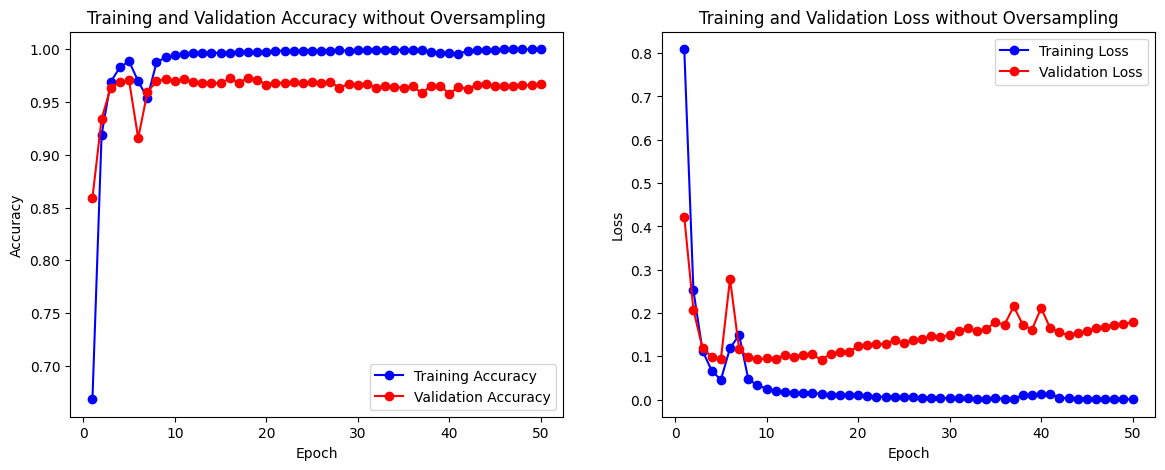

In [ ]:
import matplotlib.pyplot as plt

# Ambil data history
acc = history_null.history['accuracy']
val_acc = history_null.history['val_accuracy']
loss = history_null.history['loss']
val_loss = history_null.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy without Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss without Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Classification Report


🎯 Akurasi Model: 97.14%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     negatif     0.9782    0.9663    0.9722       742
      netral     0.9715    0.9785    0.9750       697
     positif     0.9644    0.9697    0.9670       726

    accuracy                         0.9714      2165
   macro avg     0.9714    0.9715    0.9714      2165
weighted avg     0.9714    0.9714    0.9714      2165



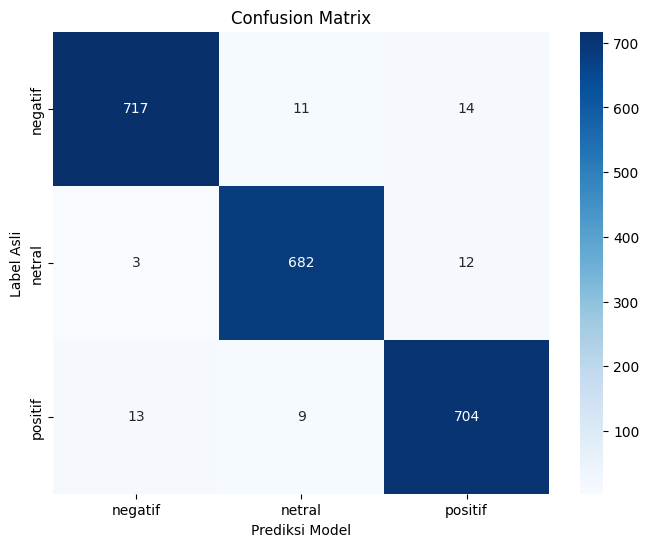

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prediksi data Test
y_pred_prob = model_static.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Decode label angka kembali ke teks
target_names = label_encoder.classes_

# ============================
# AKURASI MODEL
# ============================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model: {accuracy * 100:.2f}%")

# ============================
# CLASSIFICATION REPORT
# ============================
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

# ============================
# CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()

## Uji Coba Dengan Oversampling

### Arsitektur Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model_static_over = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.2),

    Dense(len(label_encoder.classes_), activation='softmax')
])

model_static_over.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_static_over.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Konfigurasi Pelatihan

In [ ]:
print("\n--- Training Baseline LSTM Model ---")
history_over = model_static_over.fit(
    X_train_resampled,
    y_train_resampled, # Use y_train_resampled directly after fixing the previous cell
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)


--- Training Baseline LSTM Model ---
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6375 - loss: 0.8211 - val_accuracy: 0.8279 - val_loss: 0.4642
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9202 - loss: 0.2586 - val_accuracy: 0.9480 - val_loss: 0.1687
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9704 - loss: 0.1128 - val_accuracy: 0.9648 - val_loss: 0.1159
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9813 - loss: 0.0701 - val_accuracy: 0.9677 - val_loss: 0.0994
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9865 - loss: 0.0484 - val_accuracy: 0.9723 - val_loss: 0.0955
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9903 - loss: 0.0387 - val_accuracy: 0.9671 - val_loss: 0.1052
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9909 - loss: 0.0365 - val_accuracy: 0.9682 - val_loss: 0.1179
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9935 - l

### Learning Curves

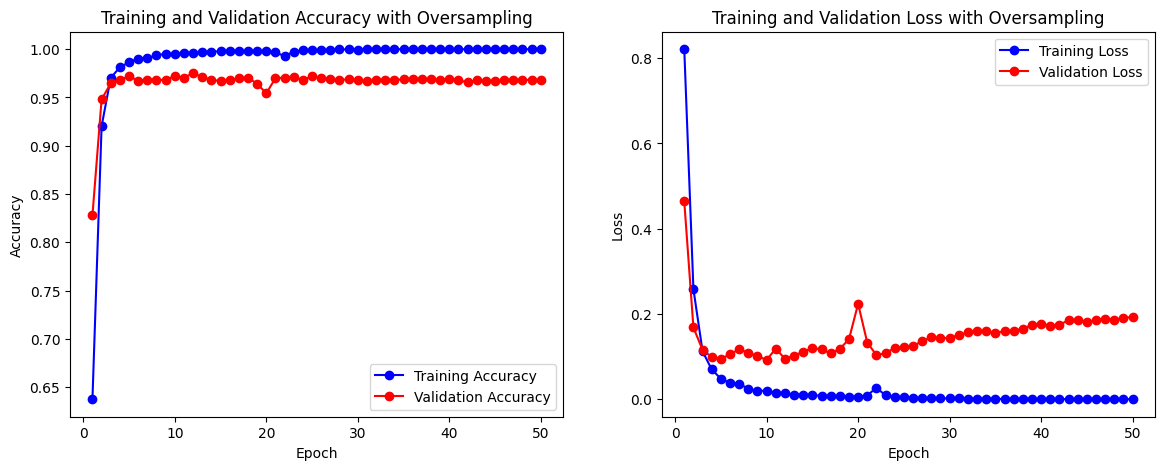

In [ ]:
import matplotlib.pyplot as plt

# Ambil data history
acc = history_over.history['accuracy']
val_acc = history_over.history['val_accuracy']
loss = history_over.history['loss']
val_loss = history_over.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss with Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Classification Report & Confusion Matrix


🎯 Akurasi Model Oversampling: 96.58%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     negatif     0.9714    0.9596    0.9654       742
      netral     0.9564    0.9756    0.9659       697
     positif     0.9695    0.9628    0.9661       726

    accuracy                         0.9658      2165
   macro avg     0.9657    0.9660    0.9658      2165
weighted avg     0.9659    0.9658    0.9658      2165



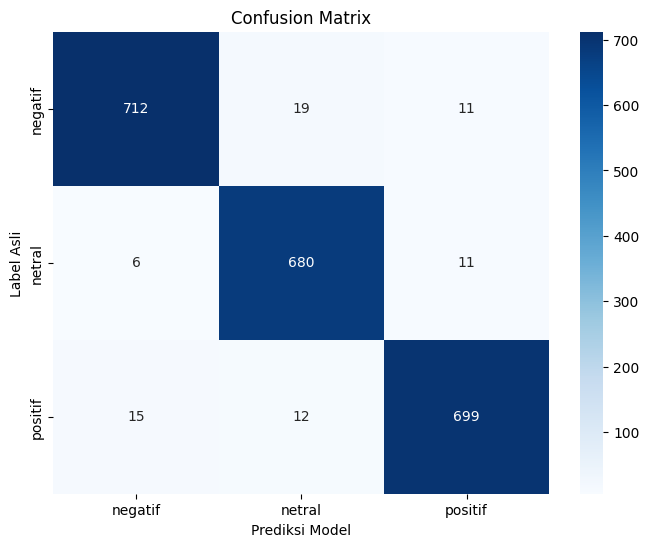

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prediksi data Test
y_pred_prob = model_static_over.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Decode label angka kembali ke teks
target_names = label_encoder.classes_

# ============================
# AKURASI MODEL
# ============================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model Oversampling: {accuracy * 100:.2f}%")

# ============================
# CLASSIFICATION REPORT
# ============================
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()


# Model LTSM Tuning

## Uji coba tanpa oversampling

### Arsitektur Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_tuned = Sequential([

    # Embedding: ubah kata menjadi vektor numerik (pakai Word2Vec)
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ),

    # Dropout embedding untuk cegah overfitting
    SpatialDropout1D(0.3),

    # BiLSTM 1: baca urutan kata dari dua arah
    Bidirectional(LSTM(128, return_sequences=True)),

    # BiLSTM 2: ambil pola lebih dalam
    Bidirectional(LSTM(64, return_sequences=True)),

    # Ambil fitur paling penting
    GlobalMaxPooling1D(),

    # Dense layer untuk klasifikasi
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output 3 kelas: positif, negatif, netral
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Compile model
model_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_tuned.summary()

# Stop jika val_loss tidak membaik
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Turunkan learning rate jika stagnan
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │       731,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,900 (2.79 MB)

 Trainable params: 731,900 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

### Konfigurasi Pelatihan

In [ ]:
print("\n--- Training Baseline LSTM Model ---")
history_null = model_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)


--- Training Baseline LSTM Model ---
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.4273 - loss: 1.0681 - val_accuracy: 0.5595 - val_loss: 1.0183
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5681 - loss: 0.9666 - val_accuracy: 0.6305 - val_loss: 0.8747
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6513 - loss: 0.8582 - val_accuracy: 0.6726 - val_loss: 0.7799
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6931 - loss: 0.7628 - val_accuracy: 0.7130 - val_loss: 0.6914
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7292 - loss: 0.6796 - val_accuracy: 0.7558 - val_loss: 0.6169
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7574 - loss: 0.6177 - val_accuracy: 0.7852 - val_loss: 0.5511
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7916 - loss: 0.5526 - val_accuracy: 0.8164 - val_loss: 0.4765
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8258 - l

### Learning Curves

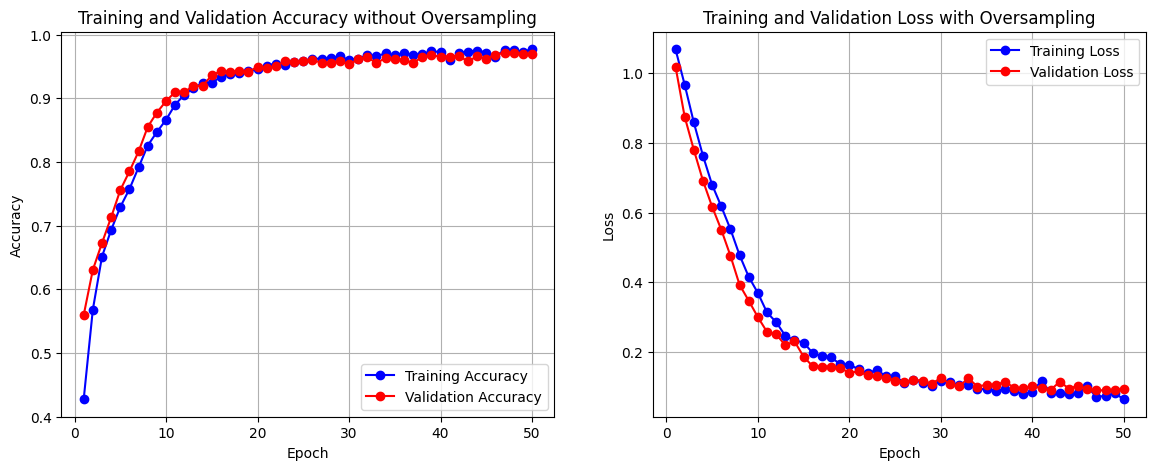

In [ ]:
import matplotlib.pyplot as plt

# Ambil data history
acc = history_null.history['accuracy']
val_acc = history_null.history['val_accuracy']
loss = history_null.history['loss']
val_loss = history_null.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy without Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss with Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.show()

### Classification Report & Confusion Matrix


🎯 Akurasi Model: 97.23%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     negatif     0.9692    0.9744    0.9718       742
      netral     0.9675    0.9813    0.9744       697
     positif     0.9803    0.9614    0.9708       726

    accuracy                         0.9723      2165
   macro avg     0.9723    0.9724    0.9723      2165
weighted avg     0.9724    0.9723    0.9723      2165



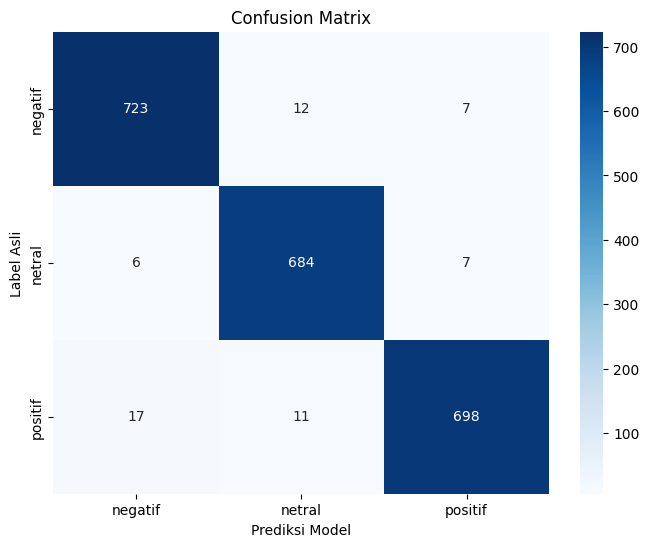

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prediksi data Test
y_pred_prob = model_tuned.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Decode label angka kembali ke teks
target_names = label_encoder.classes_

# ============================
# AKURASI MODEL
# ============================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model: {accuracy * 100:.2f}%")

# ============================
# CLASSIFICATION REPORT
# ============================
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

# ============================
# CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()

## Uji Coba dengan Oversampling

### Arsitektur Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_tuned_over = Sequential([

    # Embedding: ubah kata menjadi vektor numerik (Word2Vec)
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ),

    # Dropout pada embedding agar tidak overfitting
    SpatialDropout1D(0.3),

    # BiLSTM 1: baca konteks dua arah
    Bidirectional(LSTM(128, return_sequences=True)),

    # BiLSTM 2: ambil pola lebih kompleks
    Bidirectional(LSTM(64, return_sequences=True)),

    # Ambil fitur paling penting dari sequence
    GlobalMaxPooling1D(),

    # Dense layer untuk klasifikasi
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output 3 kelas sentimen
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Compile model
model_tuned_over.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_tuned_over.summary()

# Stop training jika val_loss tidak membaik
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Turunkan learning rate jika stagnan
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       731,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,900 (2.79 MB)

 Trainable params: 731,900 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

### Konfigurasi Pelatihan

In [ ]:
# 5. TRAINING MODEL DENGAN HYPERPARAMETER TUNING Dengan Oversampling
print("\n--- Training Tuned LSTM Model ---")
history_tuned_over = model_tuned_over.fit(
    X_train_resampled,
    y_train_resampled, # Use y_train_resampled directly after fixing the previous cell
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


--- Training Tuned LSTM Model ---
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.6427 - loss: 0.8153 - val_accuracy: 0.7916 - val_loss: 0.5162 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8682 - loss: 0.3658 - val_accuracy: 0.9428 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9343 - loss: 0.1946 - val_accuracy: 0.9492 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9591 - loss: 0.1259 - val_accuracy: 0.9561 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9683 - loss: 0.0975 - val_accuracy: 0.9579 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9701 - loss: 0.0842 - val_accuracy: 0.9636 - val_loss: 0.1031 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accur

### Learning Curves

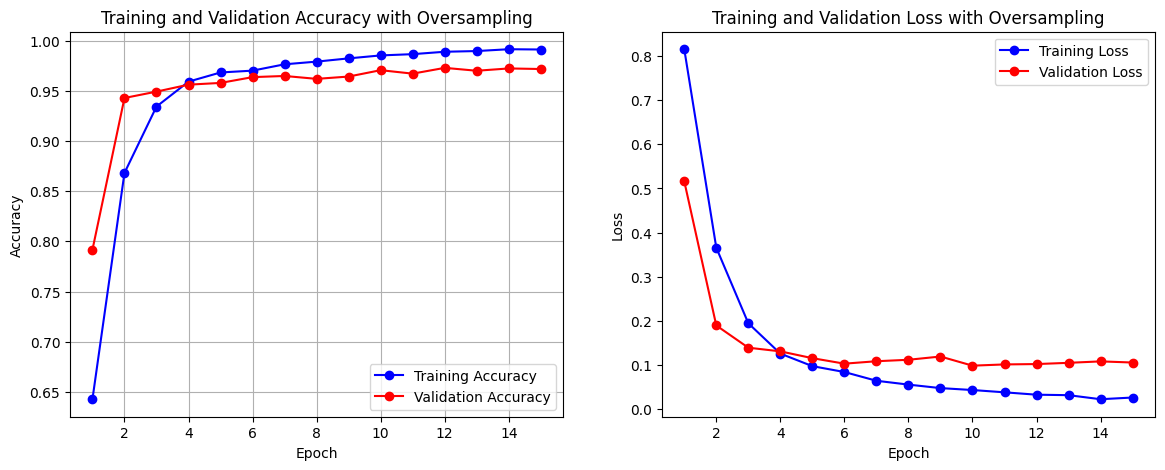

In [ ]:
import matplotlib.pyplot as plt

# Ambil data history
acc = history_tuned_over.history['accuracy']
val_acc = history_tuned_over.history['val_accuracy']
loss = history_tuned_over.history['loss']
val_loss = history_tuned_over.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.grid(True)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss with Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Clasification Report & Confusion


🎯 Akurasi Model: 97.83%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     negatif     0.9863    0.9677    0.9769       742
      netral     0.9757    0.9813    0.9785       697
     positif     0.9728    0.9862    0.9795       726

    accuracy                         0.9783      2165
   macro avg     0.9783    0.9784    0.9783      2165
weighted avg     0.9784    0.9783    0.9783      2165



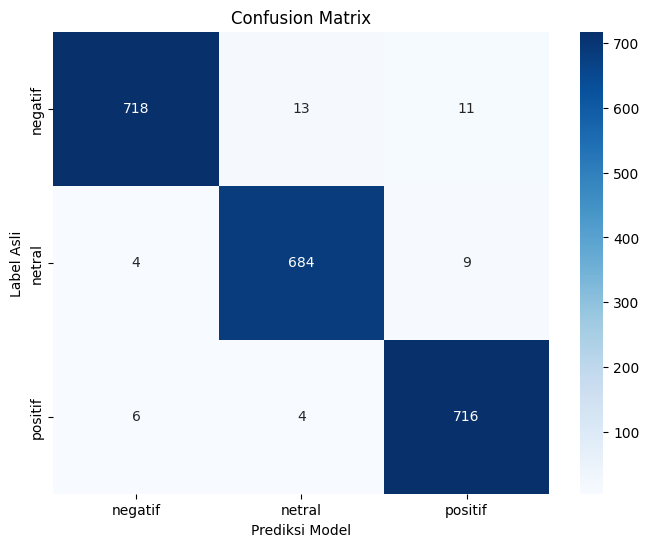

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prediksi data Test
y_pred_prob = model_tuned_over.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Decode label angka kembali ke teks
target_names = label_encoder.classes_

# ============================
# AKURASI MODEL
# ============================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model: {accuracy * 100:.2f}%")

# ============================
# CLASSIFICATION REPORT
# ============================
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
))

# ============================
# CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()


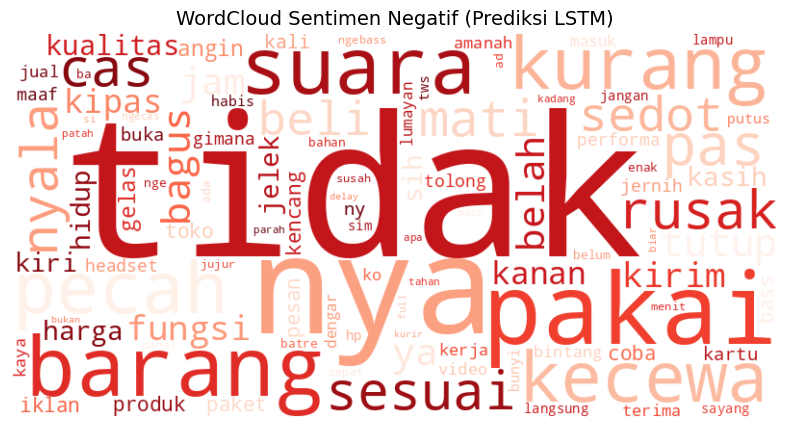


Insight Sentimen Negatif:
--------------------------------------------------
1. tidak (738 kali)
2. nya (297 kali)
3. pakai (131 kali)
4. barang (128 kali)
5. suara (117 kali)
6. kurang (116 kali)
7. pecah (114 kali)
8. kecewa (109 kali)
9. pas (71 kali)
10. cas (62 kali)

Ulasan negatif banyak memuat kata tidak, nya, pakai, barang, suara,
yang mengindikasikan adanya keluhan terkait kualitas, pengiriman, atau pelayanan.



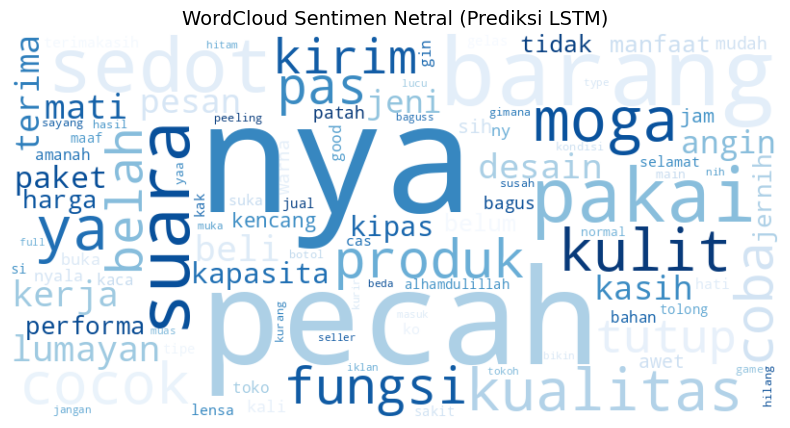


Insight Sentimen Netral:
--------------------------------------------------
1. nya (143 kali)
2. pecah (103 kali)
3. barang (92 kali)
4. sedot (56 kali)
5. pakai (56 kali)
6. suara (52 kali)
7. moga (36 kali)
8. ya (36 kali)
9. kulit (33 kali)
10. kualitas (33 kali)

Sentimen netral didominasi kata nya, pecah, barang, sedot, pakai,
menunjukkan ulasan cenderung informatif tanpa emosi kuat.



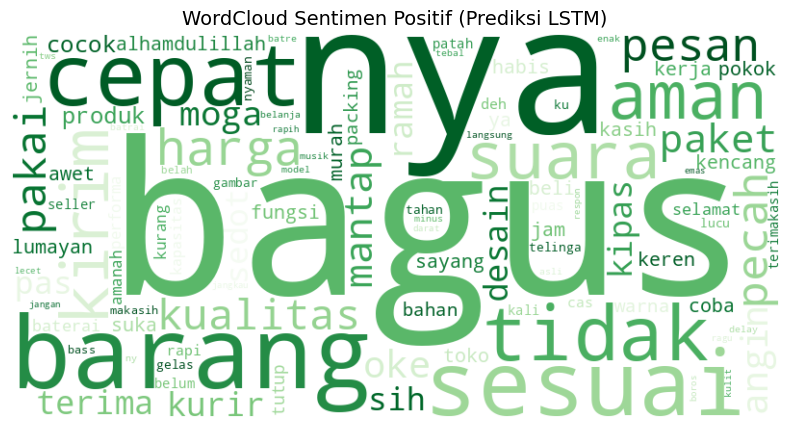


Insight Sentimen Positif:
--------------------------------------------------
1. bagus (402 kali)
2. nya (274 kali)
3. barang (211 kali)
4. sesuai (165 kali)
5. cepat (154 kali)
6. tidak (118 kali)
7. aman (88 kali)
8. kirim (85 kali)
9. suara (85 kali)
10. harga (78 kali)

Mayoritas ulasan positif didominasi kata seperti bagus, nya, barang, sesuai, cepat,
menunjukkan pelanggan merasa puas terhadap kualitas produk maupun layanan.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np

# =========================
# REKONSTRUKSI DATA TEST
# =========================
original_indices = np.arange(len(dataset))

_, test_indices = train_test_split(
    original_indices,
    test_size=0.2,
    stratify=y, # Changed from y_encoded to y
    random_state=42
)

df_test = dataset.iloc[test_indices].copy()

df_test["label_asli"] = label_encoder.inverse_transform(y_test)
df_test["label_prediksi"] = label_encoder.inverse_transform(y_pred)

# =========================
# KUMPULKAN TEKS PER KELAS
# =========================
teks_per_kelas = {}

for label in label_encoder.classes_:
    teks = df_test[df_test["label_prediksi"] == label]["hasil_stemming"]
    teks_per_kelas[label] = " ".join(teks.dropna().astype(str))

# =========================
# FUNGSI WORDCLOUD + INSIGHT
# =========================
def tampilkan_wordcloud(teks, judul, label, colormap='viridis'):
    if teks.strip() == "":
        print(f"Tidak ada data untuk {judul}")
        return

    # WordCloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
        collocations=False,
        colormap=colormap
    ).generate(teks)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(judul, fontsize=14)
    plt.show()

    # =========================
    # INSIGHT TOP WORD
    # =========================
    kata = teks.split()
    frekuensi = Counter(kata)
    top_kata = frekuensi.most_common(10)

    print(f"\nInsight Sentimen {label.capitalize()}:")
    print("-"*50)

    for i, (word, count) in enumerate(top_kata, 1):
        print(f"{i}. {word} ({count} kali)")

    # Insight narasi otomatis
    kata_utama = ", ".join([x[0] for x in top_kata[:5]])

    if label == "positif":
        print(f"\nMayoritas ulasan positif didominasi kata seperti {kata_utama},")
        print("menunjukkan pelanggan merasa puas terhadap kualitas produk maupun layanan.\n")

    elif label == "negatif":
        print(f"\nUlasan negatif banyak memuat kata {kata_utama},")
        print("yang mengindikasikan adanya keluhan terkait kualitas, pengiriman, atau pelayanan.\n")

    elif label == "netral":
        print(f"\nSentimen netral didominasi kata {kata_utama},")
        print("menunjukkan ulasan cenderung informatif tanpa emosi kuat.\n")


# =========================
# TAMPILKAN WORDCLOUD
# =========================
color_map = {
    "positif": "Greens",
    "netral": "Blues",
    "negatif": "Reds"
}

for label in label_encoder.classes_:
    current_colormap = color_map.get(label, 'viridis')

    tampilkan_wordcloud(
        teks_per_kelas[label],
        f"WordCloud Sentimen {label.capitalize()} (Prediksi LSTM)",
        label,
        colormap=current_colormap
    )

In [ ]:
df_test[["hasil_stemming", "label_asli", "label_prediksi"]].to_csv(
    "hasil_prediksi_lstm.csv",
    index=False,
    encoding="utf-8-sig"
)


In [ ]:
df_test[["hasil_stemming", "label_asli", "label_prediksi"]].head()

,hasil_stemming,label_asli,label_prediksi
10134,tidak tutup,negatif,negatif
3260,sukaaaaa lucuuuu angin muantaaappzzz,netral,netral
1316,pasang kartu telepon jam,netral,netral
10323,sedot pecah,netral,netral
10517,gelas nya lucu syang nya sedot nya pecah dua p...,positif,positif


In [ ]:
tabel_perbandingan = df_test[[
    "hasil_stemming",
    "label_asli",
    "label_prediksi"
]].copy()

tabel_perbandingan.head(10)


,hasil_stemming,label_asli,label_prediksi
10134,tidak tutup,negatif,negatif
3260,sukaaaaa lucuuuu angin muantaaappzzz,netral,netral
1316,pasang kartu telepon jam,netral,netral
10323,sedot pecah,netral,netral
10517,gelas nya lucu syang nya sedot nya pecah dua p...,positif,positif
7839,barang busuk nyala belah cas sbelah toko tak a...,netral,netral
10061,bagus si packing an nya kurang bagus sedot nya...,positif,positif
9999,bagus sih sayang rumah pecah perhati cr bungku...,positif,positif
3011,sorry late post kipas bagus tidak kendala kiri...,positif,positif
4992,performa bagus,positif,positif


In [ ]:
tabel_perbandingan["keterangan"] = np.where(
    tabel_perbandingan["label_asli"] == tabel_perbandingan["label_prediksi"],
    "Benar",
    "Salah"
)

tabel_perbandingan.head(10)


,hasil_stemming,label_asli,label_prediksi,keterangan
10134,tidak tutup,negatif,negatif,Benar
3260,sukaaaaa lucuuuu angin muantaaappzzz,netral,netral,Benar
1316,pasang kartu telepon jam,netral,netral,Benar
10323,sedot pecah,netral,netral,Benar
10517,gelas nya lucu syang nya sedot nya pecah dua p...,positif,positif,Benar
7839,barang busuk nyala belah cas sbelah toko tak a...,netral,netral,Benar
10061,bagus si packing an nya kurang bagus sedot nya...,positif,positif,Benar
9999,bagus sih sayang rumah pecah perhati cr bungku...,positif,positif,Benar
3011,sorry late post kipas bagus tidak kendala kiri...,positif,positif,Benar
4992,performa bagus,positif,positif,Benar


In [ ]:
tabel_salah = tabel_perbandingan[
    tabel_perbandingan["keterangan"] == "Salah"
]

tabel_salah.head(10)


,hasil_stemming,label_asli,label_prediksi,keterangan
1275,kualitas tidak bagus tali buka pasang jha kope...,negatif,positif,Salah
9841,gelas nya pecah kecewa bagus gelas nya,netral,negatif,Salah
9225,performance suara kurang bagus lumayan harga k...,negatif,netral,Salah
5140,alhmdllh paket nya bagus kurang gede tp tidak ...,netral,positif,Salah
10749,bahan bau plaatik ukur oke desain mayan karakt...,netral,positif,Salah
5239,performa sistem lancar tidak hambat,positif,netral,Salah
5634,bilang nya kpadebu nempel kursi tidak kesedotg...,positif,negatif,Salah
1194,produk gagal kasih costumer beli harga diskon ...,negatif,netral,Salah
1624,bagus kurang sesuai tidak masuk hp,positif,negatif,Salah
7994,henset nya murah saking murah nya henset belah...,positif,negatif,Salah


In [ ]:
tabel_benar = tabel_perbandingan[
    tabel_perbandingan["keterangan"] == "Benar"
]

tabel_benar.head(10)


,hasil_stemming,label_asli,label_prediksi,keterangan
10134,tidak tutup,negatif,negatif,Benar
3260,sukaaaaa lucuuuu angin muantaaappzzz,netral,netral,Benar
1316,pasang kartu telepon jam,netral,netral,Benar
10323,sedot pecah,netral,netral,Benar
10517,gelas nya lucu syang nya sedot nya pecah dua p...,positif,positif,Benar
7839,barang busuk nyala belah cas sbelah toko tak a...,netral,netral,Benar
10061,bagus si packing an nya kurang bagus sedot nya...,positif,positif,Benar
9999,bagus sih sayang rumah pecah perhati cr bungku...,positif,positif,Benar
3011,sorry late post kipas bagus tidak kendala kiri...,positif,positif,Benar
4992,performa bagus,positif,positif,Benar


In [ ]:
contoh_salah = tabel_salah.sample(10, random_state=42)
contoh_benar = tabel_benar.sample(10, random_state=42)

contoh_salah



,hasil_stemming,label_asli,label_prediksi,keterangan
3923,tidak sesuai pesansaya beli barang proses kemb...,netral,positif,Salah
7078,kirim cepat barang gagal dengar musik kepala g...,negatif,positif,Salah
8009,pakai minggu rusak belah produk bagus eh tidak...,positif,netral,Salah
1279,jam nya jelek besar mending beli asli kualitas,netral,negatif,Salah
8459,tws cepat lowbatsangattt kecewa,negatif,netral,Salah
5729,kualitas kerja bungkus robek kapasitas desain ...,negatif,netral,Salah
1288,tidak fitur hand gesture susah kendara pencet ...,positif,negatif,Salah
843,kiipas nya terima sesuai gambar angin nya kura...,negatif,netral,Salah
10749,bahan bau plaatik ukur oke desain mayan karakt...,netral,positif,Salah
6723,ter dabessssttttpengiriman cepatseller fast re...,positif,netral,Salah


In [ ]:
contoh_benar

,hasil_stemming,label_asli,label_prediksi,keterangan
2773,barang sipp barang,netral,netral,Benar
8189,kurang bagus cepat rusak tidak cas,negatif,negatif,Benar
3910,paket bagus kemas barang nya,positif,positif,Benar
783,kurang volum fungsi volum tidak pengaruh tenga...,negatif,negatif,Benar
6465,coba moga cocok,netral,netral,Benar
790,kipasy oke keren ganti ac tidak kuat panas keb...,positif,positif,Benar
10302,kecewa sedot pecah,negatif,negatif,Benar
3947,selamat,netral,netral,Benar
858,kurang muas kanangin nya kurangdan cepat panas...,negatif,negatif,Benar
8737,suara bocor,netral,netral,Benar
